# Support Vector Machines - Exercise 1

In this exercise, we'll be using support vector machines (SVMs) to build a spam classifier.  We'll start with SVMs on some simple 2D data sets to see how they work.  Then we'll do some pre-processing work on a set of raw emails and build a classifier on the processed emails using a SVM to determine if they are spam or not.

The first thing we're going to do is look at a simple 2-dimensional data set and see how a linear SVM works on the data set for varying values of C (similar to the regularization term in linear/logistic regression).  Let's load the data.
## Exercise 1
#### 1. Load libraries

In [58]:
import sys
import sklearn
import numpy as np
import pandas as pd
import seaborn as sns
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from scipy.io import loadmat
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

#### 2. Load data
Load the file *ejer_1_data1.mat*. Find the way for loading this kind of file. **scipy.io.loadmat**

In [2]:
data1 = loadmat('data/ejer_1_data1.mat')

In [3]:
data1

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Sun Nov 13 14:28:43 2011',
 '__version__': '1.0',
 '__globals__': [],
 'X': array([[1.9643  , 4.5957  ],
        [2.2753  , 3.8589  ],
        [2.9781  , 4.5651  ],
        [2.932   , 3.5519  ],
        [3.5772  , 2.856   ],
        [4.015   , 3.1937  ],
        [3.3814  , 3.4291  ],
        [3.9113  , 4.1761  ],
        [2.7822  , 4.0431  ],
        [2.5518  , 4.6162  ],
        [3.3698  , 3.9101  ],
        [3.1048  , 3.0709  ],
        [1.9182  , 4.0534  ],
        [2.2638  , 4.3706  ],
        [2.6555  , 3.5008  ],
        [3.1855  , 4.2888  ],
        [3.6579  , 3.8692  ],
        [3.9113  , 3.4291  ],
        [3.6002  , 3.1221  ],
        [3.0357  , 3.3165  ],
        [1.5841  , 3.3575  ],
        [2.0103  , 3.2039  ],
        [1.9527  , 2.7843  ],
        [2.2753  , 2.7127  ],
        [2.3099  , 2.9584  ],
        [2.8283  , 2.6309  ],
        [3.0473  , 2.2931  ],
        [2.4827  , 2.0373  ],
        [2.5057 

In [4]:
data1.keys()

dict_keys(['__header__', '__version__', '__globals__', 'X', 'y'])

#### 3. Create a DataFrame with the features and target

In [8]:
# Extraer la matriz 'X' del archivo
X = data1['X']

# Convertir a DataFrame
df = pd.DataFrame(X, columns=['X1', 'X2'])  
df ['y'] = data1 ['y']
df

,X1,X2,y
0,1.964300,4.5957,1
1,2.275300,3.8589,1
2,2.978100,4.5651,1
3,2.932000,3.5519,1
4,3.577200,2.8560,1
5,4.015000,3.1937,1
6,3.381400,3.4291,1
7,3.911300,4.1761,1
8,2.782200,4.0431,1
9,2.551800,4.6162,1


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      51 non-null     float64
 1   X2      51 non-null     float64
 2   y       51 non-null     uint8  
dtypes: float64(2), uint8(1)
memory usage: 999.0 bytes


In [10]:
df.describe()

,X1,X2,y
count,51.000000,51.000000,51.000000
mean,2.268780,3.132512,0.411765
std,0.928531,0.753256,0.497050
min,0.086405,1.617700,0.000000
25%,1.572550,2.636000,0.000000
50%,2.275300,3.070900,0.000000
75%,2.955050,3.531400,1.000000
max,4.015000,4.616200,1.000000


In [11]:
df['y'].value_counts()

y
0    30
1    21
Name: count, dtype: int64

#### 4. Plot a scatterplot with the data

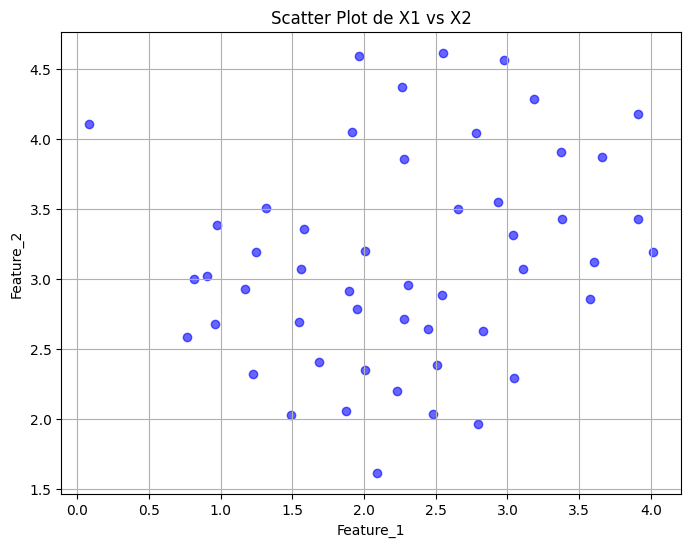

In [7]:
plt.figure(figsize=(8, 6))
plt.scatter(df['X1'], df['X2'], color='blue', alpha=0.6)
plt.title('Scatter Plot de X1 vs X2')
plt.xlabel('Feature_1')
plt.ylabel('Feature_2')
plt.grid(True)
plt.show()

<Axes: xlabel='X1', ylabel='X2'>

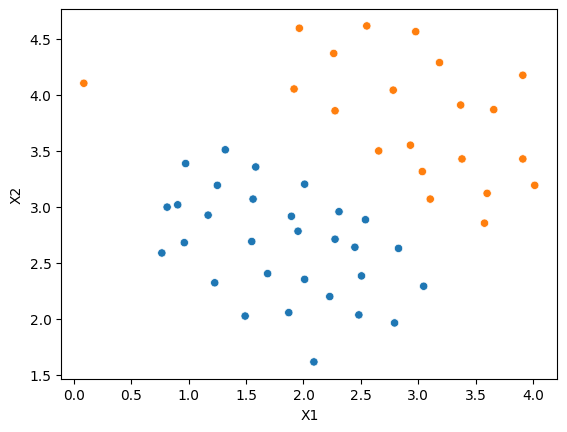

In [ ]:
sns.scatterplot(data=df, x='X1', y='X2', hue='y', legend=False)

Notice that there is one outlier positive example that sits apart from the others.  The classes are still linearly separable but it's a very tight fit.  We're going to train a linear support vector machine to learn the class boundary.

#### 5. LinearSVC
Declare a Linear SVC with the hyperparamenters:

```Python
LinearSVC(C=1, loss='hinge', max_iter=10000)
```

In [14]:
X = df[['X1', 'X2']]
y = df['y']

In [16]:

svm_clf1 = LinearSVC(C=1, loss="hinge", random_state=10, max_iter = 10000)
svm_clf1.fit(X,y)

LinearSVC(C=1, loss='hinge', max_iter=10000, random_state=10)

#### 6. Try the performance (score)
For the first experiment we'll use C=1 and see how it performs.

In [18]:
svm_clf1.score(X,y)

0.9803921568627451

It appears that it mis-classified the outlier.

#### 7. Increase the value of C until you get a perfect classifier

In [23]:
svm_clf2 = LinearSVC(C=500, loss="hinge", max_iter = 10000, random_state=10)
svm_clf2.fit(X,y)

c:\Users\amaci\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC(C=500, loss='hinge', max_iter=10000, random_state=10)

In [24]:
svm_clf2.score(X,y)

1.0

This time we got a perfect classification of the training data, however by increasing the value of C we've created a decision boundary that is no longer a natural fit for the data.  We can visualize this by looking at the confidence level for each class prediction, which is a function of the point's distance from the hyperplane.

#### 8. Plot Decission Function
Get the `decision_function()` output for the first model. Plot a scatterplot with X1, X2 and a range of colors based on `decision_function()`

In [28]:
conf = svm_clf1.decision_function(X)

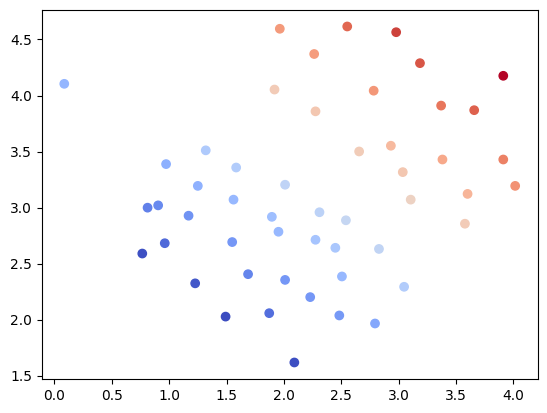

In [30]:
plt.scatter(df['X1'], df['X2'], c=conf, cmap = 'coolwarm') # Es como un Heatmap

#### 9. Do the same with the second model

https://www.svm-tutorial.com/2015/06/svm-understanding-math-part-3/

In [31]:
conf2 = svm_clf2.decision_function(X)

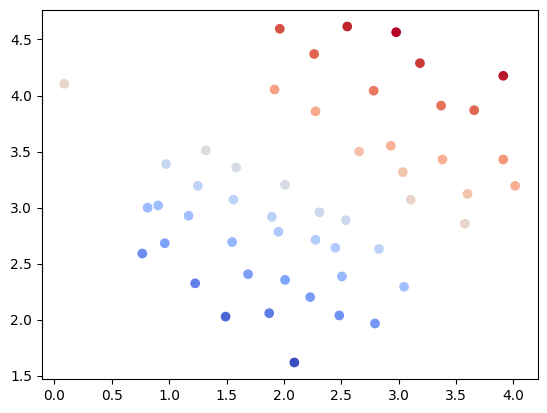

In [32]:
plt.scatter(df['X1'], df['X2'], c=conf2, cmap = 'coolwarm') # Es como un Heatmap

y = ax1 + bx2 + c

0 = ax1 + bx2 + c

bx2 = -ax1 - c

x2 = (-a/b)x1 - c/b

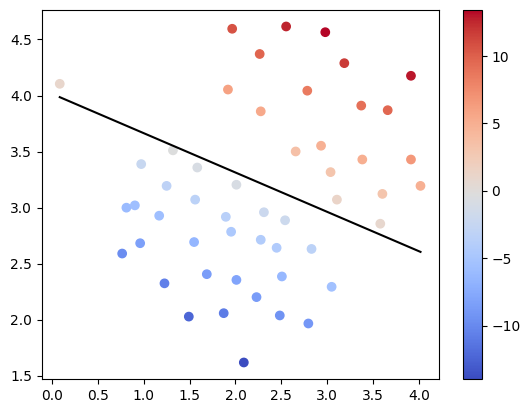

In [35]:
w = svm_clf2.coef_[0]
b = svm_clf2.intercept_ 
x_points = df['X1'].sort_values()
y_points = -w[0]/w[1]*x_points - b/w[1]

plt.scatter(df['X1'], df['X2'], c=conf2, cmap = 'coolwarm')
plt.plot(x_points, y_points, c='k')
plt.colorbar();

In [36]:
def grafico (modelo, coef):
    w = modelo.coef_[0]
    b = modelo.intercept_ 
    x_points = df['X1'].sort_values()
    y_points = -w[0]/w[1]*x_points - b/w[1]

    plt.scatter(df['X1'], df['X2'], c=coef, cmap = 'coolwarm')
    plt.plot(x_points, y_points, c='k')
    plt.colorbar()
    

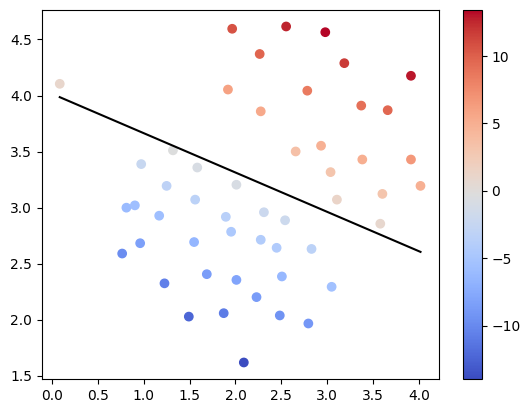

In [37]:
grafico (svm_clf2, conf2)

Now we're going to move from a linear SVM to one that's capable of non-linear classification using kernels.  We're first tasked with implementing a gaussian kernel function.  Although scikit-learn has a gaussian kernel built in, for transparency we'll implement one from scratch.

## Exercise 2

That result matches the expected value from the exercise.  Next we're going to examine another data set, this time with a non-linear decision boundary.

#### 1. Load the data `ejer_1_data2.mat`

In [39]:
data2 = loadmat('data/ejer_1_data2.mat')

In [40]:
data2.keys()

dict_keys(['__header__', '__version__', '__globals__', 'X', 'y'])

#### 2. Create a DataFrame with the features and target

In [47]:
# Extraer la matriz 'X' del archivo
X = data2['X']

# Convertir a DataFrame
df2 = pd.DataFrame(X, columns=['X1', 'X2'])  
df2 ['y'] = data2 ['y']
df2

,X1,X2,y
0,0.107143,0.603070,1
1,0.093318,0.649854,1
2,0.097926,0.705409,1
3,0.155530,0.784357,1
4,0.210829,0.866228,1
...,...,...,...
858,0.994240,0.516667,1
859,0.964286,0.472807,1
860,0.975806,0.439474,1
861,0.989631,0.425439,1


#### 3. Plot a scatterplot with the data

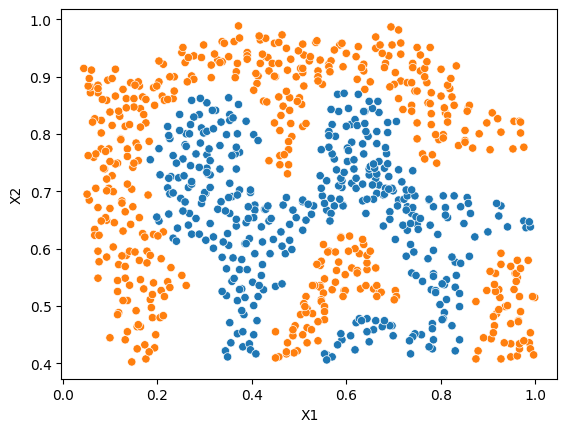

In [44]:
sns.scatterplot(data=df2, x='X1', y='X2', hue='y', legend=False);

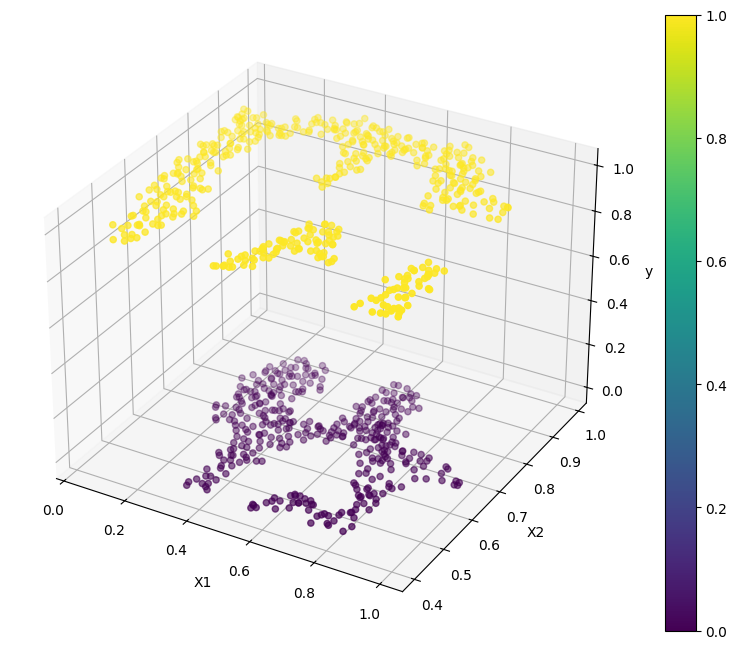

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter3D(df2['X1'], df2['X2'], df2['y'], 
                       c=df2['y'],  
                       cmap='viridis')  

ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('y')

plt.colorbar(scatter)

For this data set we'll build a support vector machine classifier using the built-in RBF kernel and examine its accuracy on the training data.  To visualize the decision boundary, this time we'll shade the points based on the predicted probability that the instance has a negative class label.  We'll see from the result that it gets most of them right.

#### 4. Declare a SVC with this hyperparameters
```Python
SVC(C=100, gamma=10, probability=True)
```


In [53]:
X = df2[['X1','X2']]
y = df2['y']

In [76]:
svc_3 = SVC(C=100, gamma=10, probability=True)
svc_3.fit(X,y)



SVC(C=100, gamma=10, probability=True)

#### 5. Fit the classifier and get the score

In [75]:
svc_3.score(X,y)

0.9698725376593279

#### 6. Plot the scatter plot and probability of predicting 0 with a [sequential color](https://matplotlib.org/3.1.1/tutorials/colors/colormaps.html)

In [77]:
pred = svc_3.predict_proba(X)
pred

array([[3.0000009e-14, 1.0000000e+00],
       [3.0000009e-14, 1.0000000e+00],
       [3.0000009e-14, 1.0000000e+00],
       ...,
       [3.0000009e-14, 1.0000000e+00],
       [3.0000009e-14, 1.0000000e+00],
       [3.0000009e-14, 1.0000000e+00]], shape=(863, 2))

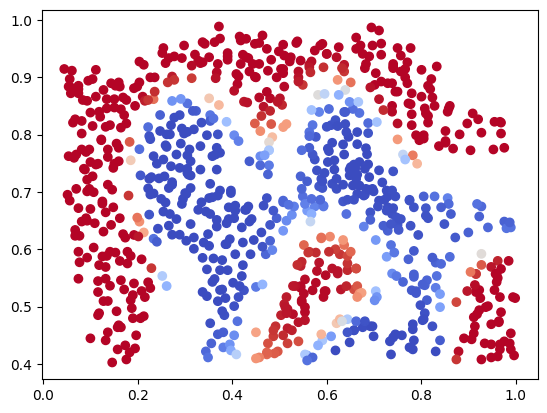

In [78]:
plt.scatter(df2['X1'], df2['X2'], c=pred[:,1], cmap = 'coolwarm');

### HACEMOS UN GRIDSEARCH

In [79]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state=10)

print (X_train.shape)
print (y_train.shape)
print (X_test.shape)
print (y_test.shape)

(690, 2)
(690,)
(173, 2)
(173,)


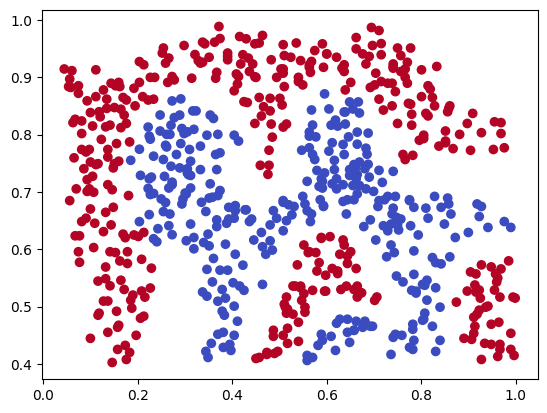

In [82]:
plt.scatter(X_train ['X1'], X_train ['X2'], c=y_train, cmap = 'coolwarm' );

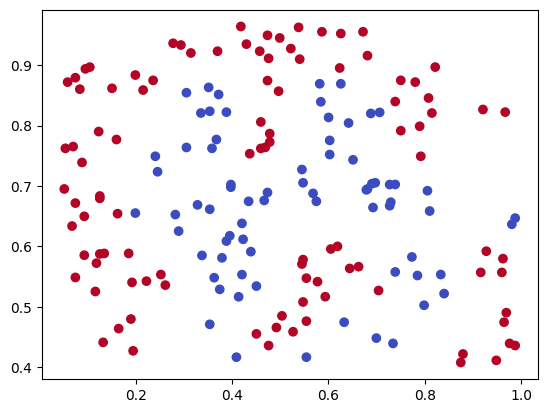

In [83]:
plt.scatter(X_test ['X1'], X_test ['X2'], c=y_test, cmap = 'coolwarm' );

In [ ]:
parametros = {
    'kernel': ['rbf', 'poly'],
    'C': [0.1,1,10,100]
}
gs = GridSearchCV(svc_3, parametros, cv = 5, scoring='accuracy', n_jobs=-1, verbose=3)
gs.fit (X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


GridSearchCV(cv=5, estimator=SVC(C=100, gamma=10, probability=True), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'kernel': ['rbf', 'poly']},
             scoring='accuracy', verbose=3)

In [85]:
print (gs.best_estimator_)
print (gs.best_params_)
print (gs.best_score_)

SVC(C=100, gamma=10, probability=True)
{'C': 100, 'kernel': 'rbf'}
0.9681159420289855
